In [1]:
using Pkg
Pkg.activate("..")   # activate project environment

using Plots
using LaTeXStrings

using NPZ # for numpy-compatible file reading and writing

using DataFrames
using GLM # for linear regression

using Revise # automatically sync src updates
using SkyrmionTunnelling
const ST = SkyrmionTunnelling # alias for easier coding

  Activating project at `~/Documents/GitHub/skyrmion-tunnelling`
[ Info: Precompiling SkyrmionTunnelling [51d433a5-d9a2-4638-a6de-06b0503db32e] (cache misses: include_dependency fsize change (2))


SkyrmionTunnelling

# Phase portraits

In [33]:
length_scale = []
skyrmion = []
instanton_sol = []
for i = 200:25:500
    l = i / 100
    push!(length_scale, l)

    filename = "../data/k26b40_new/l"*string(i)*".npy"
    push!(skyrmion, npzread(filename))

    filename = "../data/k26b40_sol/l"*string(Int(100*l))*".npy"
    push!(instanton_sol, npzread(filename))
end

In [ ]:
i = 1
xmin, xmax = -1.3, 1.3
system = microscopic_system(length_scale=length_scale[i], k=2.6, b=4.0, n_sites=skyrmion[i].size[2])
coord = LambdaCoordinate(ST.w_project(skyrmion[i]))

function reflect_xy(sol)
    sol_ref = similar(sol)
    sol_ref[1,:] .= sol[2,:]; sol_ref[2,:] .= sol[1,:]
    return sol_ref
end

function direction_vector(angle)
    return (cos(pi*angle/180), sin(pi*angle/180))
end

function phase_portrait(system, coord; xmin=-1.3, xmax=1.3, instanton, T=30, dt=0.05)
    P = plot(aspect_ratio=:equal, xlims=(xmin,xmax),ylims=(xmin,xmax), xlabel=L"\lambda", ylabel=L"\bar{\lambda}")

    sol_list = [instanton]
    colour_list = [:orange]

    push!(sol_list, reflect_xy(instanton))
    push!(colour_list, :orange)

    i = argmin(abs2.(instanton[1,:]+instanton[2,:]))
    d0 = abs(instanton[1,i])

    # add cycles in the region D
    for (x0,y0) in ( (-d0/3,d0/3), (-d0*2/3,d0*2/3))
        sol = solve_ivp([x0,y0], system,coord, dt=dt,T=T)
        push!(sol_list, sol)
        push!(colour_list, :lightblue)
    end

    # add open solutions
    for (x0,y0) in ( (1.1, 1.1), (-1.1,-1.1), (d0+0.1,-d0-0.1) )
        sol1 = solve_ivp([x0,y0], system,coord, dt=dt,T=T)
        sol2 = solve_ivp(sol1[:,1], system,coord, dt=-dt,T=T)
        sol = hcat(sol2[:,end:-1:1], sol1)
        push!(sol_list, sol)
        push!(colour_list, :lightblue)

        push!(sol_list, reflect_xy(sol))
        push!(colour_list, :lightblue)
    end

    IJulia.clear_output()

    for i=1:length(sol_list)
        sol = sol_list[i]
        ST.plot_sol!(P, sol; system=system, coord=coord, xmin=xmin,xmax=xmax, colour=colour_list[i], directions=direction_vector.([15,75,135,195,255,315]))
    end
    return P
end

phase_portrait (generic function with 1 method)

In [73]:
length_scale[7]

3.5

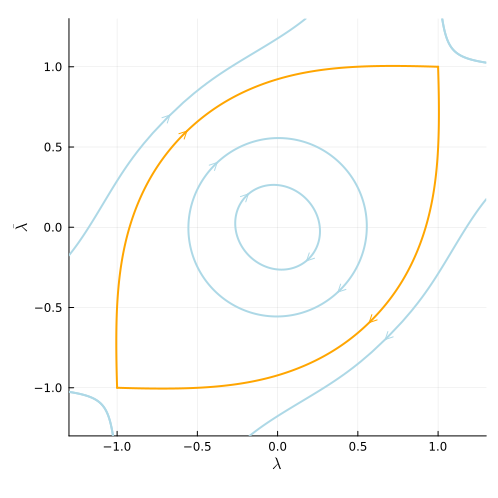

In [84]:
i = 1
xmin, xmax = -1.3, 1.3
system = microscopic_system(length_scale=length_scale[i], k=2.6, b=4.0, n_sites=skyrmion[i].size[2])
coord = LambdaCoordinate(ST.w_project(skyrmion[i]))
P1 = phase_portrait(system,coord, instanton=instanton_sol[i], T=30, dt=0.05)

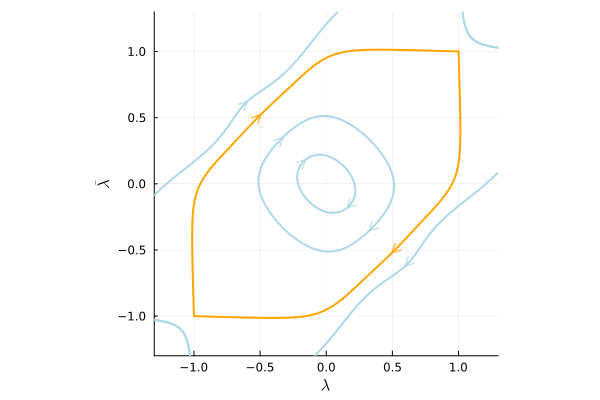

In [76]:
i = 7
xmin, xmax = -1.3, 1.3
system = microscopic_system(length_scale=length_scale[i], k=2.6, b=4.0, n_sites=skyrmion[i].size[2])
coord = LambdaCoordinate(ST.w_project(skyrmion[i]))
P2 = phase_portrait(system,coord, instanton=instanton_sol[i], T=30, dt=0.05)

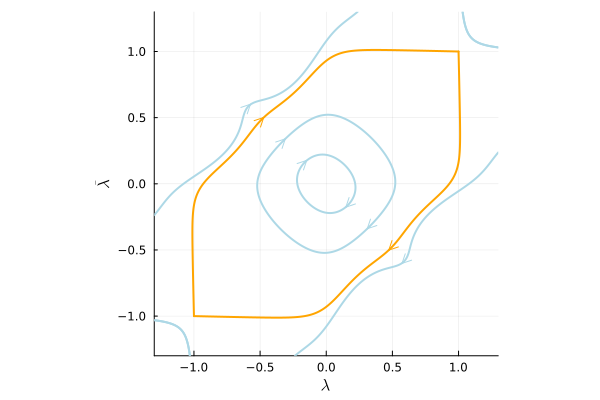

In [104]:
i = 13
xmin, xmax = -1.3, 1.3
system = microscopic_system(length_scale=length_scale[i], k=2.6, b=4.0, n_sites=skyrmion[i].size[2])
coord = LambdaCoordinate(ST.w_project(skyrmion[i]))
P3 = phase_portrait(system,coord, instanton=instanton_sol[i], T=100, dt=0.1)

In [ ]:
show_phase_portrait(system,coord,xmin=-1.3,xmax=1.3)

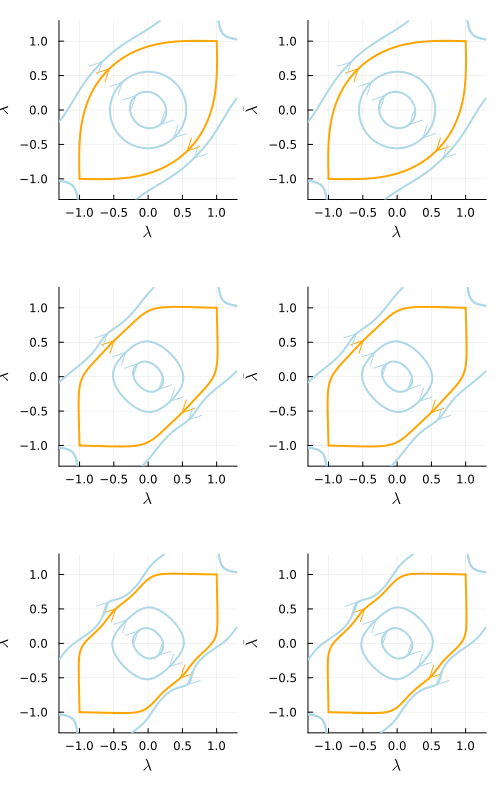

In [105]:
l = @layout [a b ; c d ; e f]
plot(P1,P1,P2,P2,P3,P3, size = (500,800), layout=l)

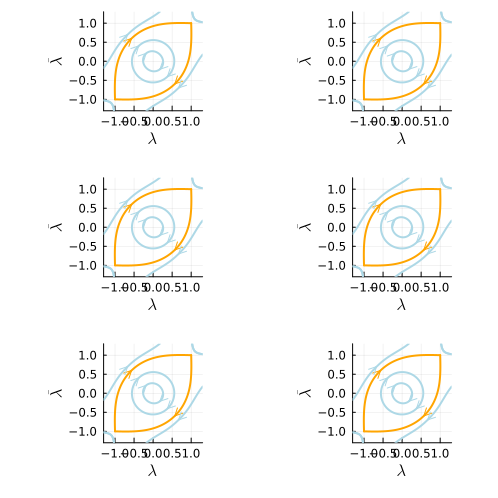

In [86]:
plot(P1,P1,P1,P1,P1,P1, layout = @layout [a b ; c d ; e f])